<a href="https://colab.research.google.com/github/jcdumlao14/ESS11e04_1_DataAnalysis/blob/main/Country_Level_Analysis_Stressor_Means_(95_CI)_and_Odds_Ratios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import zipfile
from sklearn.metrics import roc_auc_score, brier_score_loss
import warnings
import os

warnings.filterwarnings("ignore")


# **LOAD DATA**

In [2]:
# LOAD DATA

zip_path = '/content/ESS11e04_1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ESS11e04_1.csv') as f:
        df = pd.read_csv(f, low_memory=False)

# Filter working adults 18-65
df = df[(df['pdwrk'] == 1) & (df['agea'] >= 18) & (df['agea'] <= 65)].copy()

missing_codes = [7, 8, 9, 66, 77, 88, 99, 666, 777, 888, 999]


# **REGION MAPPING**

In [3]:
# REGION MAPPING

region_map = {
    'NO': 'North', 'SE': 'North', 'DK': 'North', 'FI': 'North', 'IS': 'North', 'GB': 'North', 'IE': 'North',
    'FR': 'West', 'BE': 'West', 'NL': 'West', 'LU': 'West', 'DE': 'West', 'AT': 'West',
    'ES': 'South', 'PT': 'South', 'IT': 'South', 'GR': 'South', 'CY': 'South', 'MT': 'South',
    'PL': 'East', 'CZ': 'East', 'SK': 'East', 'HU': 'East', 'RO': 'East', 'BG': 'East', 'SI': 'East', 'HR': 'East'
}

def get_region(code):
    if pd.isna(code):
        return 'Unknown'
    return region_map.get(str(code).upper(), 'Unknown')

df['region'] = df['cntry'].apply(get_region)


# COUNTRY NAME MAPPING

country_names = {
    'NO': 'Norway', 'SE': 'Sweden', 'DK': 'Denmark', 'FI': 'Finland',
    'IS': 'Iceland', 'GB': 'United Kingdom', 'IE': 'Ireland',
    'FR': 'France', 'BE': 'Belgium', 'NL': 'Netherlands', 'LU': 'Luxembourg',
    'DE': 'Germany', 'AT': 'Austria',
    'ES': 'Spain', 'PT': 'Portugal', 'IT': 'Italy', 'GR': 'Greece',
    'CY': 'Cyprus', 'MT': 'Malta',
    'PL': 'Poland', 'CZ': 'Czech Republic', 'SK': 'Slovakia',
    'HU': 'Hungary', 'RO': 'Romania', 'BG': 'Bulgaria',
    'SI': 'Slovenia', 'HR': 'Croatia'
}

df['country_name'] = df['cntry'].map(country_names)
df['Country'] = df['country_name'].fillna('Unknown')

In [4]:
# OUTCOME & CONTROLS

df['CVD'] = pd.to_numeric(df['hltprhc'], errors='coerce').replace(missing_codes, np.nan)
df['age'] = pd.to_numeric(df['agea'], errors='coerce')
df['gender'] = df['gndr'].map({1:'Male', 2:'Female'})
df['edu'] = pd.to_numeric(df['eduyrs'], errors='coerce').replace(missing_codes, np.nan)


# DEMANDS & RESOURCES

physical_vars = ['jbexpvi','jbexpti','jbexpml','jbexpmc']
existing_physical_vars = [v for v in physical_vars if v in df.columns]
df['dem_physical'] = df[existing_physical_vars].apply(pd.to_numeric, errors='coerce').replace(missing_codes,0).sum(axis=1) if existing_physical_vars else np.nan

df['dem_workload'] = pd.to_numeric(df['wkhtot'], errors='coerce').replace(missing_codes,np.nan) if 'wkhtot' in df.columns else np.nan
df['dem_financial'] = pd.to_numeric(df['hincfel'], errors='coerce').replace(missing_codes,np.nan) if 'hincfel' in df.columns else np.nan

resource_vars = ['wkdcorga','wkdcorgb','wkdcorgc']
existing_resource_vars = [v for v in resource_vars if v in df.columns]
df['res_control'] = df[existing_resource_vars].apply(pd.to_numeric, errors='coerce').replace(missing_codes,np.nan).mean(axis=1) if existing_resource_vars else np.nan


# **COUNTRY SUMMARY FUNCTION**

In [5]:
# COUNTRY SUMMARY FUNCTION

def get_stats(group):
    clean = group.dropna()
    n = len(clean)
    if n==0:
        return pd.Series({'N':0,'Mean':np.nan,'Std':np.nan,'SE':np.nan,'CI (95%)':"N/A"})
    mean = clean.mean()
    std = clean.std()
    se = std/np.sqrt(n)
    ci_low = mean - 1.96*se
    ci_high = mean + 1.96*se
    return pd.Series({'N':n,'Mean':round(mean,3),'Std':round(std,3),'SE':round(se,3),'CI (95%)':f"[{ci_low:.3f},{ci_high:.3f}]"})


# ANALYSIS + PLOT

def run_analysis(var_name, save_dir='plots'):
    print(f"\n=== {var_name.upper()} BY COUNTRY ===")

    os.makedirs(save_dir, exist_ok=True)

    # Drop missing countries for summary
    df_var = df[[var_name,'Country']].dropna(subset=['Country'])

    # Summary stats
    stats_output = df_var.groupby('Country')[var_name].apply(get_stats).unstack()

    # Prepare logistic regression per country
    model_cols = ['CVD','age','gender','edu',var_name,'Country']
    df_model = df[model_cols].copy()

    # Only drop NaN in predictor/outcome columns, keep Country
    df_model = df_model.dropna(subset=['CVD','age','gender','edu',var_name,'Country'])
    df_model['CVD'] = df_model['CVD'].apply(lambda x:1 if x==1 else 0)

    results=[]
    for country,d in df_model.groupby('Country'):
        if len(d) < 30:
            continue
        try:
            model = smf.logit(f"CVD~age+gender+edu+{var_name}", data=d).fit(disp=0)
            or_val = np.exp(model.params[var_name])
            p_val = model.pvalues[var_name]
            y_true = d['CVD']
            y_pred = model.predict(d)
            auc = roc_auc_score(y_true, y_pred)
            brier = brier_score_loss(y_true, y_pred)
            results.append({'Country':country,'OR':round(or_val,4),'p_value':round(p_val,4),'auc':round(auc,4),'brier_score':round(brier,4)})
        except:
            continue

    metrics = pd.DataFrame(results).set_index('Country')
    final = stats_output.join(metrics, how='outer')

    # Display table
    display(final[['N','Mean','Std','SE','CI (95%)','OR','p_value','auc','brier_score']])

    # ----- PLOT -----
    plt.figure(figsize=(12,6))
    x = np.arange(len(final))
    y = final['Mean'].values
    yerr = (final['SE']*1.96).values if 'SE' in final.columns else None

    plt.bar(x, y, yerr=yerr, capsize=5, color=plt.cm.viridis(x/len(x)))
    plt.xticks(x, final.index, rotation=90)
    plt.ylabel("Mean")
    plt.title(f"{var_name} Mean by Country with 95% CI")

    if 'OR' in final.columns:
        ax2 = plt.twinx()
        ax2.plot(x, final['OR'].values, color='red', marker='o', label='OR')
        ax2.set_ylabel("OR", color='red')
        ax2.tick_params(axis='y', colors='red')
        ax2.legend(loc='upper right')

    plt.tight_layout()

    # Save plot
    save_path = os.path.join(save_dir, f"{var_name}_by_country.png")
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved to: {save_path}")

    plt.show()


# **MULTILEVEL MODEL (COUNTRY EFFECTS)**

In [6]:
# MULTILEVEL MODEL (COUNTRY EFFECTS)

def run_multilevel_model():
    print("\n=== MULTILEVEL MODEL (COUNTRY EFFECTS) ===")

    # Prepare data
    cols = ['CVD','age','gender','edu','dem_physical','dem_workload','dem_financial','res_control','Country']
    df_model = df[cols].dropna()

    df_model['CVD'] = df_model['CVD'].apply(lambda x:1 if x==1 else 0)
    df_model['gender'] = df_model['gender'].astype('category')

    formula = "CVD ~ age + gender + edu + dem_physical + dem_workload + dem_financial + res_control"

    model = mixedlm(formula, data=df_model, groups=df_model["Country"])
    result = model.fit(reml=True)

    print(result.summary())


# **RUN ALL ANALYSES**


=== DEM_PHYSICAL BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,1117,0.799,1.109,0.033,"[0.734,0.865]",1.3173,0.0380,0.6669,0.0404
Belgium,788,1.029,1.103,0.039,"[0.952,1.106]",1.0996,0.5276,0.6440,0.0511
Bulgaria,1083,0.604,0.88,0.027,"[0.551,0.656]",1.1716,0.3275,0.7079,0.0481
Croatia,690,0.923,1.073,0.041,"[0.843,1.003]",1.2108,0.2818,0.6797,0.0386
Cyprus,324,0.62,0.967,0.054,"[0.515,0.726]",1.0207,0.9445,0.7399,0.0306
Finland,788,1.549,1.274,0.045,"[1.461,1.638]",1.2653,0.0737,0.6943,0.0511
France,918,1.179,1.178,0.039,"[1.102,1.255]",1.0229,0.8780,0.6251,0.0411
Germany,1370,1.103,1.194,0.032,"[1.040,1.166]",1.2539,0.0044,0.6031,0.0809
Greece,1561,0.696,0.899,0.023,"[0.652,0.741]",0.8774,0.5717,0.7457,0.0160


Plot saved to: plots/dem_physical_by_country.png


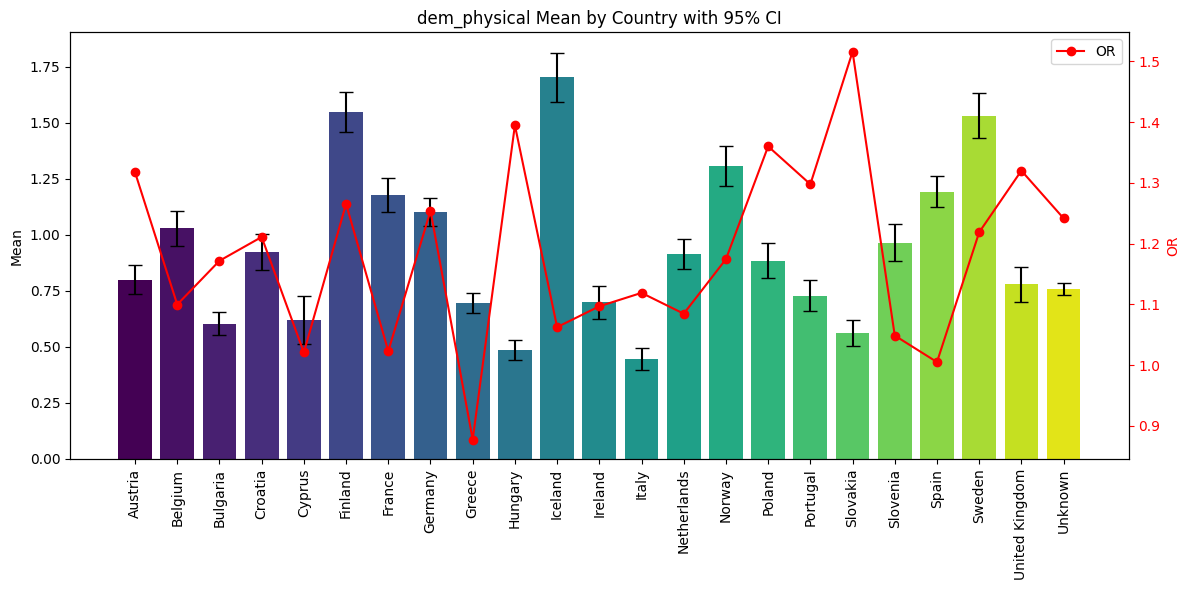


=== DEM_WORKLOAD BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,1052,37.812,9.016,0.278,"[37.267,38.357]",0.9823,0.2846,0.6590,0.0407
Belgium,771,40.267,15.982,0.576,"[39.139,41.395]",1.0170,0.0475,0.6518,0.0506
Bulgaria,992,44.418,11.15,0.354,"[43.724,45.112]",1.0146,0.1319,0.7172,0.0496
Croatia,670,42.387,10.973,0.424,"[41.556,43.217]",1.0051,0.7572,0.6834,0.0398
Cyprus,316,41.212,17.313,0.974,"[39.303,43.121]",0.9820,0.3540,0.7787,0.0312
Finland,775,36.987,12.262,0.44,"[36.124,37.850]",0.9997,0.9818,0.6716,0.0497
France,896,39.026,12.36,0.413,"[38.216,39.835]",1.0096,0.3309,0.6245,0.0418
Germany,1348,37.226,11.699,0.319,"[36.601,37.850]",1.0044,0.6273,0.5790,0.0820
Greece,1511,43.834,12.423,0.32,"[43.207,44.460]",0.9854,0.3682,0.7086,0.0141


Plot saved to: plots/dem_workload_by_country.png


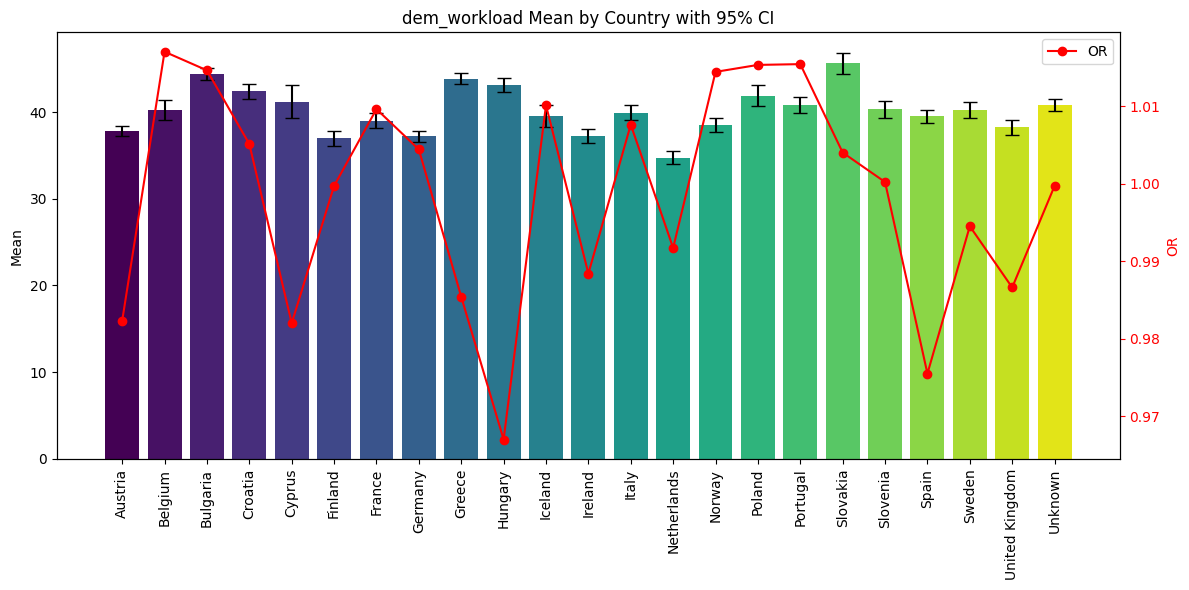


=== DEM_FINANCIAL BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,1110,1.77,0.654,0.02,"[1.732,1.809]",1.8038,0.0072,0.6854,0.0405
Belgium,787,1.595,0.708,0.025,"[1.545,1.644]",0.8810,0.6147,0.6378,0.0511
Bulgaria,1079,2.277,0.736,0.022,"[2.233,2.321]",0.6421,0.0495,0.7224,0.0483
Croatia,684,1.735,0.675,0.026,"[1.685,1.786]",0.6556,0.2126,0.6879,0.0388
Cyprus,319,2.003,0.845,0.047,"[1.910,2.096]",2.9221,0.0105,0.8556,0.0304
Finland,787,1.71,0.626,0.022,"[1.667,1.754]",1.8477,0.0118,0.7021,0.0510
France,916,1.706,0.695,0.023,"[1.661,1.751]",1.1698,0.5137,0.6310,0.0412
Germany,1367,1.541,0.635,0.017,"[1.508,1.575]",1.3182,0.0589,0.5926,0.0814
Greece,1538,2.317,0.725,0.018,"[2.280,2.353]",0.8584,0.5889,0.7449,0.0163


Plot saved to: plots/dem_financial_by_country.png


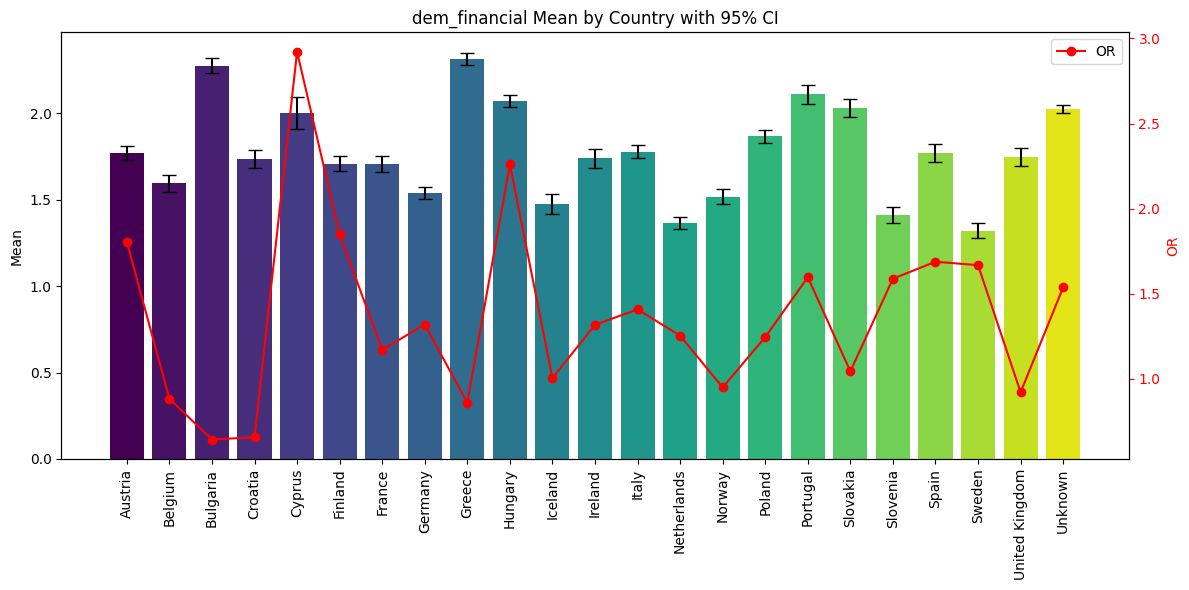


=== RES_CONTROL BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,720,5.971,3.225,0.12,"[5.735,6.206]",0.8888,0.0452,0.6707,0.0471
Belgium,349,7.069,3.681,0.197,"[6.683,7.455]",1.0668,0.4219,0.7115,0.0517
Bulgaria,849,4.975,3.806,0.131,"[4.719,5.231]",1.0556,0.2033,0.7329,0.0522
Croatia,477,4.7,3.849,0.176,"[4.355,5.046]",0.9502,0.3985,0.7529,0.0413
Cyprus,216,5.977,3.988,0.271,"[5.445,6.509]",1.2280,0.1266,0.8636,0.0305
Finland,304,7.312,3.384,0.194,"[6.932,7.693]",0.9825,0.8151,0.6752,0.0619
France,527,6.56,3.864,0.168,"[6.230,6.890]",1.0025,0.9647,0.6564,0.0507
Germany,706,7.293,3.433,0.129,"[7.040,7.546]",0.9579,0.2765,0.5520,0.0852
Greece,1170,5.92,3.664,0.107,"[5.710,6.130]",1.0220,0.7429,0.7830,0.0146


Plot saved to: plots/res_control_by_country.png


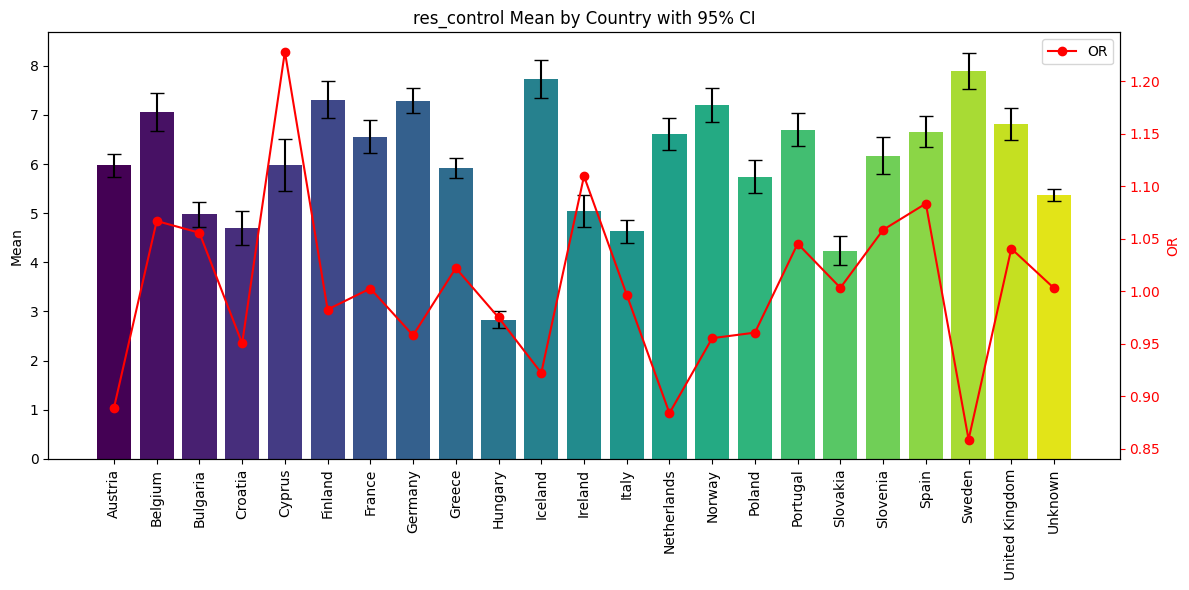


=== MULTILEVEL MODEL (COUNTRY EFFECTS) ===
          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: CVD      
No. Observations:   13947   Method:             REML     
No. Groups:         23      Scale:              0.0477   
Min. group size:    198     Log-Likelihood:     1372.7493
Max. group size:    3204    Converged:          Yes      
Mean group size:    606.4                                
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      -0.076    0.014 -5.401 0.000 -0.104 -0.049
gender[T.Male] -0.005    0.004 -1.270 0.204 -0.012  0.003
age             0.002    0.000 12.958 0.000  0.002  0.002
edu             0.000    0.001  0.463 0.643 -0.001  0.001
dem_physical    0.009    0.002  5.129 0.000  0.006  0.013
dem_workload    0.000    0.000  0.319 0.749 -0.000  0.000
dem_financial   0.012    0.003  4.743 

In [7]:
# RUN ALL ANALYSES

variables = ['dem_physical','dem_workload','dem_financial','res_control']

for var in variables:
    run_analysis(var)

# Multilevel model
run_multilevel_model()

The analysis used data from the European Social Survey (ESS11), focusing on working adults (ages 18–65).

- **Country-Level Analysis:** For each country, the **Mean** (average level) of four stressors was calculated alongside **Odds Ratios (OR)** from logistic regressions. The OR represents the risk of Cardiovascular Disease (CVD) associated with that stressor.
- **Multilevel Model:** A mixed linear model was used to analyze all countries simultaneously, controlling for individual factors like age, gender, and education to find universal trends.

# RESULTS

- **Physical Demands (dem_physical):**
  - **Plot:** Bars show high physical demands in Nordic countries (Iceland, Finland) and low levels in Italy.
  - **Result:** In many countries (e.g., Germany, Austria, Slovakia), higher physical demands are significantly linked to a higher risk of heart issues (OR > 1.2).
- **Financial Stress (dem_financial):**
  - **Plot:** Southern and Eastern European countries (Greece, Bulgaria, Portugal) report the highest financial strain.
  - **Result:** This is the most consistent risk factor. In countries like Cyprus, Hungary, and Austria, higher financial stress is strongly tied to increased CVD risk (ORs reaching 1.8 to 2.9).
- **Job Control (res_control):**
  - **Plot:** Sweden, Iceland, and Finland have the highest levels of employee autonomy, while Hungary and Slovakia have the lowest.
  - **Result:** Higher control is generally protective. In Austria and the Netherlands, more job control is significantly associated with lower CVD risk (OR < 0.9).
- **Workload (dem_workload):**
  - **Plot:** Work hours are highest in Slovakia and Bulgaria and lowest in the Netherlands.
  - **Result:** Interestingly, work hours alone showed the weakest connection to heart health, with ORs staying very close to 1.0 across most countries.


# **Multilevel Model Results**

When looking at all data points together in the **Multilevel Model**, the findings become clear:

- **Age** is a primary driver of heart health risk.
- **Physical Job Demands and Financial Stress** are the two **"work-life"** stressors that significantly increase the risk of cardiovascular disease across Europe (both p < 0.001).
- **Job Control and Total Workload** were not significant universal predictors when other factors were held constant.

# **Conclusion**
While workload varies by country, **physical strain and financial instability** are the most critical predictors of heart disease among European workers. Physical demands are particularly high in the North, while financial stress is a major burden in the South and East.